# DTL: labeling modular reference data

# 1. Process modular referencing data

In [6]:
VERSION = 'v7'
REGION = 'sumatra' # lowercase

In [7]:
import pandas as pd
import numpy as np
import json

# use the modular reference dataset was reverse engineered from KLHK map
df_train_csv = f'../data/modular_mapping_approach/{REGION}_test/{REGION}_extracted_raster_values_by_provinces_{VERSION}.csv'
df_train = pd.read_csv(df_train_csv)

df_train[['longitude', 'latitude']] = (
    df_train['.geo']
    .apply(lambda x: json.loads(x)['coordinates'])
    .apply(pd.Series)
)

df_train = df_train.drop(columns=['.geo', 'system:index'])

print(df_train.head())

    AoI  ID                    LULC_24  agricultural_activity  \
0  Aceh   1  Hutan lahan kering primer                    0.0   
1  Aceh   1  Hutan lahan kering primer                    0.0   
2  Aceh   1  Hutan lahan kering primer                    0.0   
3  Aceh   1  Hutan lahan kering primer                    0.0   
4  Aceh   1  Hutan lahan kering primer                    0.0   

   artificial_waterbody  bareSoil_cover  builtup_cover  cacao_presence  \
0                   0.0       -0.247093            0.0             0.0   
1                   0.0       -0.300814            0.0             0.0   
2                   0.0       -0.215841            0.0             0.0   
3                   0.0       -0.243787            0.0             0.0   
4                   0.0       -0.358057            0.0             0.0   

   coconut_presence  coffee_presence  ...  mining  oilpalm_presence  \
0               0.0         0.000000  ...     0.0               0.0   
1               0.0   

# 2. Define ruleset

In [8]:
# ── DEFINE RULESET ─────────────────────────────────────────────────────────
# Each row = one class rule. Columns are primitives with operators.
# Format: ">0.40" means "greater than 0.40"
#         "==1" means "equal to 1"
#         ">=25" means "greater than or equal to 25"
#         'treecover': '<30 | >80',  means treecover < 30 OR treecover > 80   
#         None means "no condition on this primitive"

ruleset_csv = f'../data/modular_mapping_approach/ruleset_epistem_default_{VERSION}.csv'
ruleset = pd.read_csv(ruleset_csv)
ruleset = ruleset.sort_values(by='priority', ascending=True)
print(ruleset)

# copy to clipboard for easy pasting into the ruleset CSV file
pd.DataFrame.to_clipboard(ruleset)

CLASS_NAMES = dict(zip(ruleset['class_id'], ruleset['class_name']))
CLASS_NAMES[0] = 'unclassified'
CLASS_NAMES[-1] = 'abstain'

    class_id                 class_name  priority waterbody_cover  \
0         23                  Waterbody         1             >=1   
1         20                  Fish Pond         2             >=1   
2         24                 Settlement         3             NaN   
3         21               Cleared Land         4             NaN   
4         22                Mining area         5             NaN   
5          9       Oil palm monoculture         6             NaN   
6         11        Coconut monoculture         7             NaN   
7         15        Rubber agroforestry         8             NaN   
8          8         Rubber monoculture         9             NaN   
9         14        Coffee agroforestry        10             NaN   
10        10          Cacao monoculture        11             NaN   
11        16          Mixed/home garden        12             NaN   
12         7          Plantation forest        13             NaN   
13        12          Other monocu

## Helper functions to label the classes

In [9]:
def safe_num(val, default=0):
    """Convert value to float, return default if None or NaN."""
    if val is None:
        return default
    if isinstance(val, (int, float)):
        if np.isnan(val):
            return default #handling empty cells in the CSV file and turn them into the set default value (0)
        return float(val)
    try:
        return float(val)
    except:
        return default

def evaluate_condition(row_val, condition_str):
    """
    Evaluate a single condition: row_val op threshold?
    Supports OR logic with pipe separator: ">0.40|<0.10"
    
    Args:
        row_val: The value from the sample
        condition_str: String like ">0.40", ">=25", ">0.40|<0.10"
    
    Returns:
        bool: True if condition is satisfied, False otherwise
    """
    if condition_str is None:
        return True  # No condition → always passes
    
    condition_str = str(condition_str).strip()
    
    # Handle OR logic (pipe-separated conditions)
    if '|' in condition_str:
        sub_conditions = [c.strip() for c in condition_str.split('|')]
        return any(evaluate_condition(row_val, c) for c in sub_conditions)

    # Handle AND logic
    if '&' in condition_str:
        sub_conditions = [c.strip() for c in condition_str.split('&')]
        return all(evaluate_condition(row_val, c) for c in sub_conditions)
    
    # Parse operator and threshold
    if condition_str.startswith('=='):
        op, threshold_str = '==', condition_str[2:]
    elif condition_str.startswith('>='):
        op, threshold_str = '>=', condition_str[2:]
    elif condition_str.startswith('<='):
        op, threshold_str = '<=', condition_str[2:]
    elif condition_str.startswith('>'):
        op, threshold_str = '>', condition_str[1:]
    elif condition_str.startswith('<'):
        op, threshold_str = '<', condition_str[1:]
    else:
        return True  # Invalid condition → pass
    
    threshold = safe_num(threshold_str)
    row_val_num = safe_num(row_val)
    
    if op == '>':
        return row_val_num > threshold
    elif op == '>=':
        return row_val_num >= threshold
    elif op == '<':
        return row_val_num < threshold
    elif op == '<=':
        return row_val_num <= threshold
    elif op == '==':
        return np.isclose(
            row_val_num,
            threshold,
            atol=1e-6
        )
    
    return False

def check_rule_match(row, rule):
    """
    Check if a sample row matches all conditions in a rule.
    
    Args:
        row: pd.Series with sample data
        rule: pd.Series with rule conditions
    
    Returns:
        bool: True if ALL conditions are satisfied
    """
    # Get all primitive columns (skip metadata like class_id, class_name, priority)
    metadata = {'class_id', 'class_name', 'priority'}
    primitive_cols = [col for col in rule.index if col not in metadata]
    
    for prim in primitive_cols:
        condition = rule[prim]
        
        # Handle special case for range checks
        if pd.isna(condition) or condition is None:
            continue  # No condition on this primitive
        
        row_val = row.get(prim, np.nan)
        
        if not evaluate_condition(row_val, condition):
            return False  # Any condition fails → rule doesn't match
    
    return True  # All conditions passed

def assign_label(row, ruleset):
    """
    Evaluate rules in priority order.

    - First matching rule returns its class_id.
    - Non-matching rules abstain (-1) and evaluation continues.
    - If every rule abstains, return 0 (unclassified).

    """
    ruleset_sorted = ruleset.sort_values("priority").reset_index(drop=True)

    for _, rule in ruleset_sorted.iterrows():
         if check_rule_match(row, rule):
            return rule["class_id"]  # first vote wins

    return 0  # all LFs abstained

print('✓ Helper functions defined')

✓ Helper functions defined


## Assign the class labels to the modular reference data

In [10]:
df_train['label'] = df_train.apply(lambda row: assign_label(row, ruleset), axis=1)

# add class_name column
class_mapping = ruleset.set_index('class_id')['class_name'].to_dict()

df_train['class_name'] = df_train['label'].map(class_mapping).fillna('unclassified')

print(f'✓ Labels assigned to {len(df_train)} samples\n')

print('Label distribution (assigned):')
print(
    df_train['class_name']
    .value_counts()
    .reindex(ruleset['class_name'].unique(), fill_value=0)
)

print(f'\nUnclassified (label=0): {(df_train["label"] == 0).sum()}')

✓ Labels assigned to 9798 samples

Label distribution (assigned):
class_name
Waterbody                     345
Fish Pond                      40
Settlement                     72
Cleared Land                  113
Mining area                     0
Oil palm monoculture          247
Coconut monoculture             0
Rubber agroforestry             0
Rubber monoculture              8
Coffee agroforestry             9
Cacao monoculture              13
Mixed/home garden             110
Plantation forest             178
Other monoculture               0
Paddy field                    90
Other Cropland                 37
Shrub                          36
Grass or Savanna              410
Primary Mangrove Forest       282
Primary Swamp Forest           78
Secondary Mangrove Forest     563
Secondary Swamp Forest        214
Primary Dryland Forest       1263
Secondary Dryland Forest     1844
Name: count, dtype: int64

Unclassified (label=0): 3846


## Compare with original class label

Classified samples: 9798



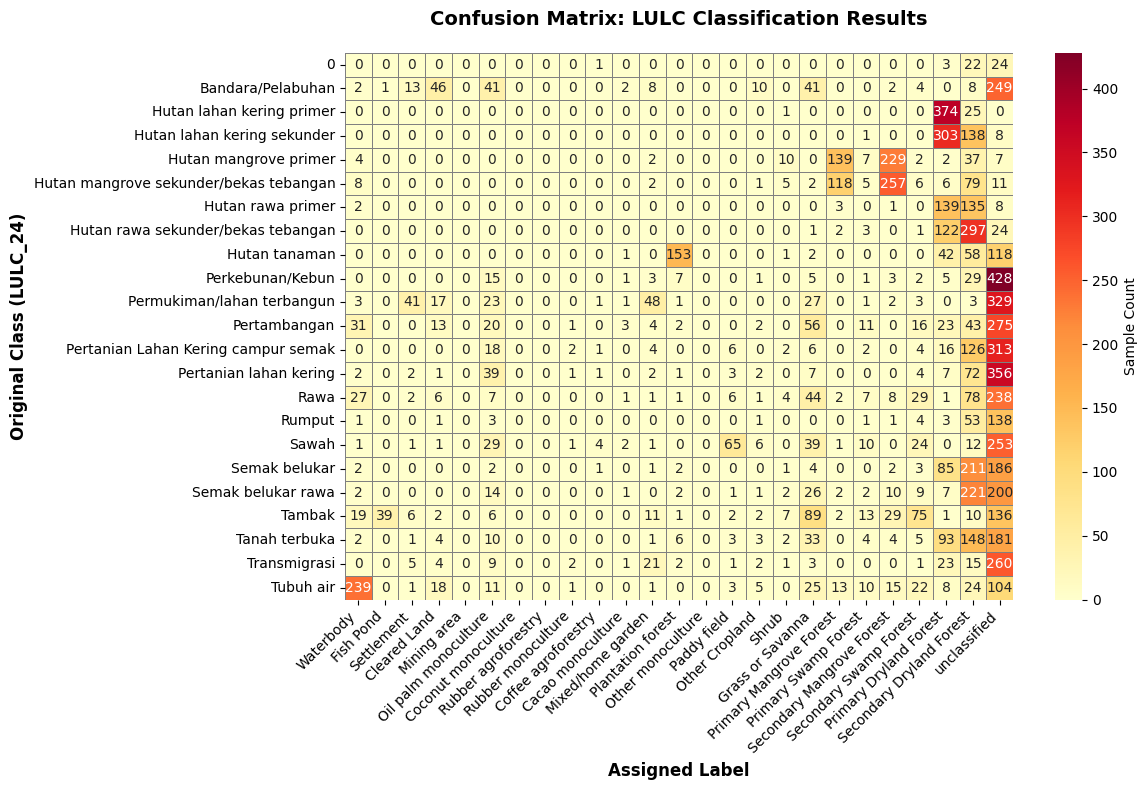

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ORIGINAL_CLASS = "LULC_24"

print(f"Classified samples: {len(df_train)}")
print()


# Complete list of target classes + unclassified
all_classes = list(ruleset["class_name"].unique()) + ["unclassified"]

# Count how many samples from each original class received each label
summary = (
    pd.crosstab(
        df_train[ORIGINAL_CLASS],
        df_train["class_name"]
    )
    .reindex(columns=all_classes, fill_value=0)
)

# for manual excel check, copy the summary to clipboard for easy pasting into Excel
summary.to_clipboard(
    excel=True,
    index=True
)

fig, ax = plt.subplots(figsize=(12, 8))
 
sns.heatmap(
    summary,
    annot=True,  # Show values
    fmt="d",      # Integer format
    cmap="YlOrRd", # Yellow-Orange-Red gradient (darker = more misclassification)
    cbar_kws={"label": "Sample Count"},
    linewidths=0.5,
    linecolor="gray",
    ax=ax
)
 
ax.set_xlabel("Assigned Label", fontsize=12, fontweight="bold")
ax.set_ylabel("Original Class (LULC_24)", fontsize=12, fontweight="bold")
ax.set_title("Confusion Matrix: LULC Classification Results", 
             fontsize=14, fontweight="bold", pad=20)
 
# Rotate labels for readability
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
 
plt.tight_layout()
# plt.savefig("confusion_matrix_heatmap.png", dpi=150, bbox_inches="tight")
# print("\n✓ Saved: confusion_matrix_heatmap.png")
plt.show()

## Save the labelled training dataset

In [12]:
import geopandas as gpd
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(df_train["longitude"], df_train["latitude"])]
gdf = gpd.GeoDataFrame(df_train, geometry=geometry, crs="EPSG:4326")
gdf.to_file(f"../data/modular_mapping_approach/{REGION}_test/{REGION}_td_DTL_result_{VERSION}.shp")

C:\Users\widijanto\AppData\Local\Temp\ipykernel_25528\3083244527.py:6: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(f"../data/modular_mapping_approach/{REGION}_test/{REGION}_td_DTL_result_{VERSION}.shp")
c:\Users\widijanto\AppData\Local\miniconda3\envs\luma-ge\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'agricultural_activity' to 'agricultur'
  ogr_write(
c:\Users\widijanto\AppData\Local\miniconda3\envs\luma-ge\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'artificial_waterbody' to 'artificial'
  ogr_write(
c:\Users\widijanto\AppData\Local\miniconda3\envs\luma-ge\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'bareSoil_cover' to 'bareSoil_c'
  ogr_write(
c:\Users\widijanto\AppData\Local\miniconda3\envs\luma-ge\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 